 Hi , I'm Ahmed Ibarhim Hassan 🕵️✋

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
# choose window 
from tkinter import Tk
from tkinter.filedialog import askopenfilename
print("libraries have loaded ✅")

libraries have loaded ✅


## هنا انا بختار الداتا الي عايز اشتغل عليها 🗂️


In [2]:
Tk().withdraw()  # يخفي النافذة الرئيسية

file_path = askopenfilename()

## Function للتعامل مع الملف المرفوع 🔍
هنا انا بحط كل الاحتمالات للمشاكل الي ممكن تواجهني سواء كانت صيغة الملف مختلفة او مشكلة ترميز

In [3]:
def load_dataset(path:str)->pd.DataFrame:
    try:
        if path.split('.')[1] == 'xlsx' : 
            df = pd.read_excel(path)
            print(f'''
                Excel File has loaded successfully ✅
                Columns : {df.shape[1]}
                Rows : {df.shape[0]}
                ''')
        elif path.split('.')[1] == 'csv':
            try:
                df = pd.read_csv(path,encoding='utf-8')
            except UnicodeDecodeError:
                print('UTF-8 format doesn\'t working - trying latin1 💥')
                try:
                    df = pd.read_csv(path,encoding='latin1')
                except UnicodeDecodeError:
                    print('latin1 format doesn\'t working')
            print(f'''
                Data has loaded successfully ✅
                Columns : {df.shape[1]}
                Rows : {df.shape[0]}
                ''')
        else:
            print('This file is not CSV or Excel file 😮')
        return df 
    except FileNotFoundError:
        print('Please select an existed file')
    except Exception as e : 
        print(f"ُError occurred {e}")

In [4]:
df = load_dataset(file_path)

UTF-8 format doesn't working - trying latin1 💥

                Data has loaded successfully ✅
                Columns : 21
                Rows : 9996
                


## ابتديت استكشف انواع الاعمدة و اغيرها للنوع المناسب

In [5]:
df.dtypes

Row ID            float64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
Country/Region        str
City                  str
State                 str
Postal Code       float64
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity          float64
Discount          float64
Profit            float64
dtype: object

#### Handling Data Types

In [6]:
df['Postal Code'] = df['Postal Code'].astype(str)
df['Quantity'] = df['Quantity'].astype('Int64')
df['Row ID'] = df['Row ID'].astype('Int64')
df['Order Date'] = pd.to_datetime(df['Order Date'],errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'],errors='coerce')

In [7]:
df.dtypes

Row ID                     Int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code                  str
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   Int64
Discount                 float64
Profit                   float64
dtype: object

## EDA (خطوات اكتر لأستكشاف الأعمدة)

#### عرض اول 5 صفوف

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#### تحديد نوع و عدد القيم المفقودة في كل عمود 

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   Int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   str           
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           
 15  Sub-Category   

#### وصف الداتا الرقمية و النصية

In [10]:
# Numeric 
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.0,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order Date,9994,2018-04-30 10:03:51.979187,2016-01-03 00:00:00,2017-05-23 00:00:00,2018-06-26 00:00:00,2019-05-14 00:00:00,2019-12-30 00:00:00,NaN
Ship Date,9994,2018-05-04 09:03:29.645787,2016-01-07 00:00:00,2017-05-27 00:00:00,2018-06-29 00:00:00,2019-05-18 00:00:00,2020-01-05 00:00:00,NaN
Sales,9994.0,229.858001,0.444,17.28,54.49,209.94,22638.48,623.245101
Quantity,9994.0,3.789574,1.0,2.0,3.0,5.0,14.0,2.22511
Discount,9994.0,0.156203,0.0,0.0,0.2,0.2,0.8,0.206452
Profit,9994.0,28.656896,-6599.978,1.72875,8.6665,29.364,8399.976,234.260108


In [11]:
# For Categorical data
df.describe(include='object').T
#top : هو القيمة الاكتر تكراراً 
#freq : هو عدد مرات تكرار القيمة دي

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_5816\2194051700.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
Order ID,9994,5009,CA-2019-100111,14
Ship Mode,9994,4,Standard Class,5968
Customer ID,9994,793,WB-21850,37
Customer Name,9994,793,William Brown,37
Segment,9994,3,Consumer,5191
Country/Region,9994,1,United States,9994
City,9994,531,New York City,915
State,9994,49,California,2001
Postal Code,9983,630,10035.0,263
Region,9994,4,West,3203


### جدول يوضح كل عمود فيه كام خلية ناقصة و ده بيمثل قد ايه من النسبة الكلية 

In [12]:
Missing_summery = pd.DataFrame({
    'Missing Values' : df.isnull().sum(),
    'Missing Percentage %': df.isnull().mean()*100
})
Missing_summery[Missing_summery['Missing Percentage %'] > 0].sort_values("Missing Values",ascending=False)

,Missing Values,Missing Percentage %
Postal Code,13,0.130052
Order ID,2,0.020008
Order Date,2,0.020008
Ship Date,2,0.020008
Row ID,2,0.020008
Ship Mode,2,0.020008
Customer ID,2,0.020008
Segment,2,0.020008
Customer Name,2,0.020008
Country/Region,2,0.020008


# الجزء الخاص بتنظيف البيانات 🧹🕵️

## Function للتعامل مع الصفوف المكررة

In [13]:
def Remove_Duplicates(data:pd.DataFrame)->pd.DataFrame:
    try:
        before = len(data)
        cleaned = data.drop_duplicates()
        after = len(cleaned)
        print(f'Number Of Duplicated Rows : {before-after} 😮')
        return cleaned
    except Exception as e :
        print(f'Error In Remove_Duplicates Function 💥 : {e}')
        return data 

In [14]:
df = Remove_Duplicates(df)

Number Of Duplicated Rows : 1 😮


## Function للتعامل مع الداتا المفقودة 🔍

In [15]:
# 👉 special columns : عبارة عن مجموعة الاعمدة الي مش عايزها تتملي بالطريقة دي  👈
# 👉 numeric Fill : لتحديد ازاي أملي الاعمدة الرقمية هل بأستخدام المتوسط ام الوسيط  👈
# ملحوظة : الاعمدة النصية بتتملي ب اكتر قيمة اتكررت في العمود ده 

def Handling_Missing_Values(dataset:pd.DataFrame , SpecialColumns=[], Numericfill = 'mean' )->pd.DataFrame:
    # Categorical data first
    try:
        data = dataset.copy()
        data = data.dropna(how='all') # If All Columns Are Null 
        data = data.replace({
            'N/a':np.nan,
            '': np.nan
        })

        numeric_columns = data.select_dtypes(include=np.number).columns
        categorical_columns = data.select_dtypes(include=['object']).columns
        date_columns = data.select_dtypes(include='datetime')
        
        # الاعمدة النصية
        for col in categorical_columns:
            if data[col].isnull().sum() > 0 and col not in SpecialColumns:
                Value = data[col].mode()[0]
                print(f'{col} has : {data[col].isnull().sum()} Missing ⚠️ it will filled by Mode : {Value}')
                data[col] = data[col].fillna(Value)
        # الاعمدة الرقمية
        for col in numeric_columns:
            if data[col].isnull().sum() > 0 and col not in SpecialColumns:
                Value = data[col].median() if Numericfill.lower() == 'median' else  data[col].mean()
                print(f'{col} has : {data[col].isnull().sum()} Missing ⚠️ it will filled by median : {Value}')
                data[col] = data[col].fillna(Value)
        # اعمدة التواريخ
        # ملحوظة : هنا ابتديت أملي القيم المفقودة ب تاربخ اعلي من الاوردر الي قبله بس اقل من تاربخ الاوردر الي بعده 
        for col in date_columns: 
            if data[col].isnull().sum()>0 and col not in SpecialColumns:
                print(f'{col} has : {data[col].isnull().sum()} Missing ⚠️ it will filled using backward/Forward Fill : {Value}')
                date_one_day_before = data[col] - pd.DateOffset(days=1) # Date Column - one day for (For Backward fill)
                date_one_day_after = data[col] + pd.DateOffset(days=1) # Date Column + one day (For Forward fill)

                data[col] = data[col].fillna( 
                    date_one_day_before.bfill() # هيملي من الي بعده 
                )

                data[col] = data[col].fillna(  # هيملي من الي قبله 
                    date_one_day_after.ffill()
                )
                
        print('Data Filled Successfully ✅')
        return data
    except Exception as e :
        print(f'Error In Handling_Missing_Values Function 💥 {e}')
            

In [16]:
# استقبال الأعمدة المستبعدة من الملئ

Flag = True 
SpecialList = []
while Flag:
    item = input("please input the special column names to be avoided \n To terminate Type 'Stop'")
    if item.lower() == 'stop':
        Flag = False
        break
    SpecialList.append(item)
    
df = Handling_Missing_Values(df,SpecialList) # Here we will not pass any thing to the Numericfill paramater so it will fill numeric fields with the median

Postal Code has : 11 Missing ⚠️ it will filled by Mode : 10035.0
Data Filled Successfully ✅


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_5816\3346110923.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include=['object']).columns


## Function للتعامل مع المسافات الغير مرغوب فيها

In [17]:
def Clean_Unwanted_Spaces(data : pd.DataFrame)->pd.DataFrame:
    try : 
        Categorical_Column = df.select_dtypes(include=['object','string'])
        for col in Categorical_Column: 
            data[col] = data[col].str.strip()
        return data
    except Exception as e : 
        print(f"Error occured in Clean_Unwanted_Spaces Function {e}")
        
df = Clean_Unwanted_Spaces(df)

In [18]:
df.columns.to_list()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

## جزء Visualization 🎯

### تحليل المبيعات عبر الزمن 💡

#### 1-Line Chart (مقارنة مبيعات السنوات)📊

In [19]:
df['Order Date'].dt.year.unique()

array([2018, 2017, 2016, 2019], dtype=int32)

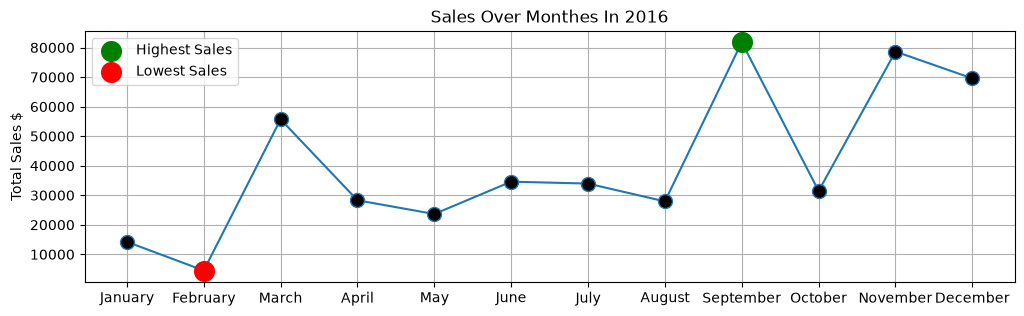

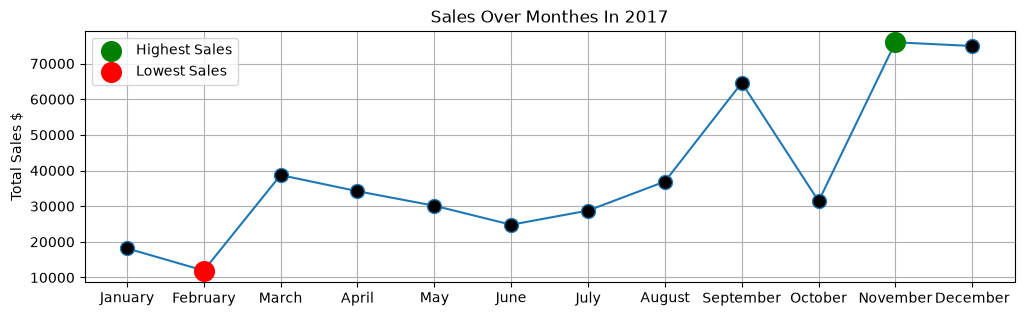

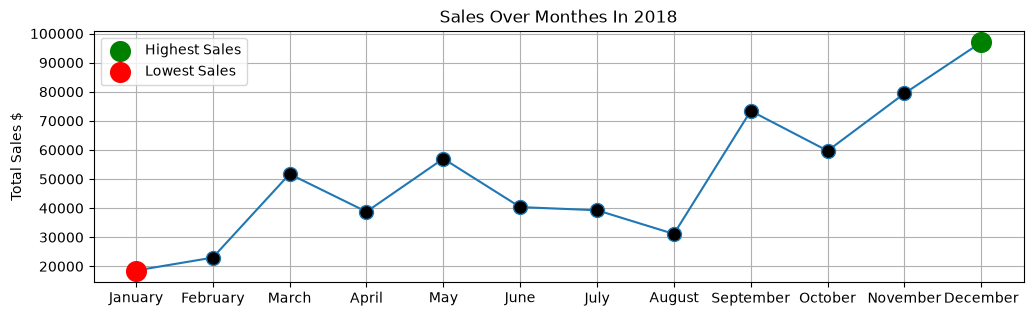

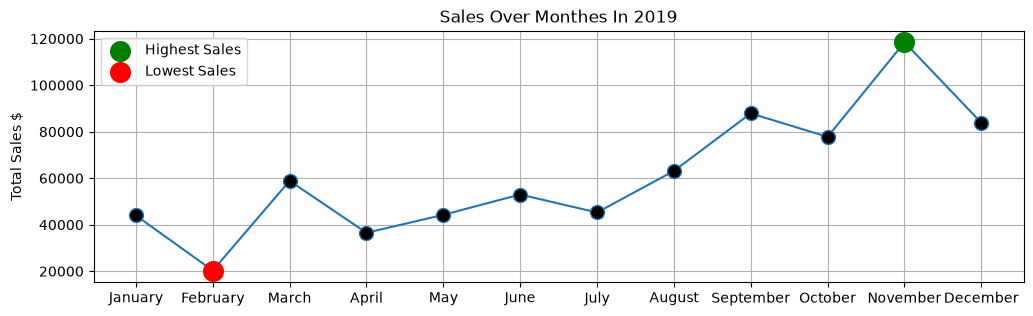

In [99]:
row = 1 # visuals row number  
sorted_years_list = sorted(df['Order Date'].dt.year.unique().tolist())

for year in sorted_years_list:
    #Creation of dfs depending on year condition 
    df_Year = df[df['Order Date'].dt.year == year].groupby(df['Order Date'].dt.month_name()).Sales.sum().reset_index(name = 'Total Sales')
    months = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
    }
    df_Year['Month_Num'] = df_Year['Order Date'].apply(lambda v : months[v])
    df_Year = df_Year.sort_values('Month_Num') 

    
    Max_id = df_Year['Total Sales'].idxmax() # To reach the highest sales row 
    Min_id = df_Year['Total Sales'].idxmin()

    plt.figure(figsize=(12,15))
    plt.subplot(4,1,row) # Grid Configuration 
    plt.title(f'Sales Over Monthes In {year}')
    plt.ylabel('Total Sales $')
    plt.grid(True)
    plt.plot(
        df_Year['Order Date'],
        df_Year['Total Sales'],
        marker ='o',
        ms = 10 ,
        mfc = 'k'
    )
    # To Put Points on graph 
    plt.scatter(
        df_Year.loc[Max_id,'Order Date'],
        df_Year.loc[Max_id,'Total Sales'],
        color = 'green',
        s = 200,
        label = 'Highest Sales',
        zorder = 5
    )
    plt.scatter(
        df_Year.loc[Min_id,'Order Date'],
        df_Year.loc[Min_id,'Total Sales'],
        color = 'red',
        s = 200,
        label = 'Lowest Sales',
        zorder = 5
    )
    plt.legend()
    row += 1


#### 2-Pie Chart (الربح عبر السنوات الماضية) 🚀

Text(0.5, 1.0, 'Total Sales Over Years')

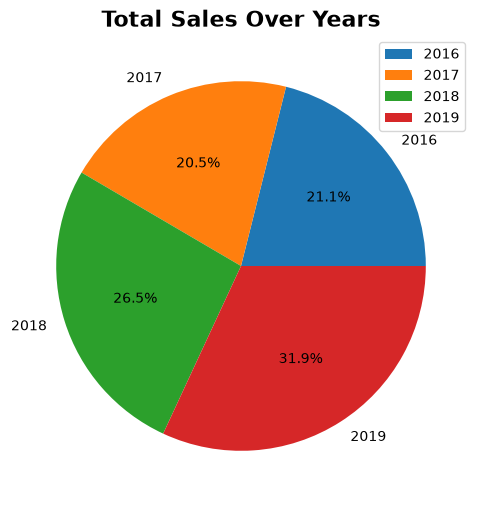

In [100]:
Sales_Years = df.groupby(df['Order Date'].dt.year).Sales.sum()

Sales_Years.plot(
    figsize=(12,6),
    kind='pie',
    y='Total Sales',
    autopct='%1.1f%%',
    legend=True
)
plt.title(
    'Total Sales Over Years',
    fontsize=16, 
    fontweight='bold'
)

##### هنا الرسمة بتوضح ان سنة 2019 اعلي سنة مبيعاً متفوقة علي 2018 📌

### تحليل المنتجات 

#### اعلي 5 منتجات من حيث الربح 💰

##### 1-Bar chart (الربح لكل منتج)

In [101]:
Top_5_Product_Sales = df.groupby('Product Name').Profit.sum().reset_index(name = 'Profit').sort_values(by='Profit',ascending=False).head(5)
Top_5_Product_Sales

,Product Name,Profit
404,Canon imageCLASS 2200 Advanced Copier,25199.9280
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
805,Hewlett Packard LaserJet 3310 Copier,6983.8836
400,Canon PC1060 Personal Laser Copier,4570.9347
787,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766


[Text(0, 0, '4094.98'),
 Text(0, 0, '4570.93'),
 Text(0, 0, '6983.88'),
 Text(0, 0, '7753.04'),
 Text(0, 0, '25199.93')]

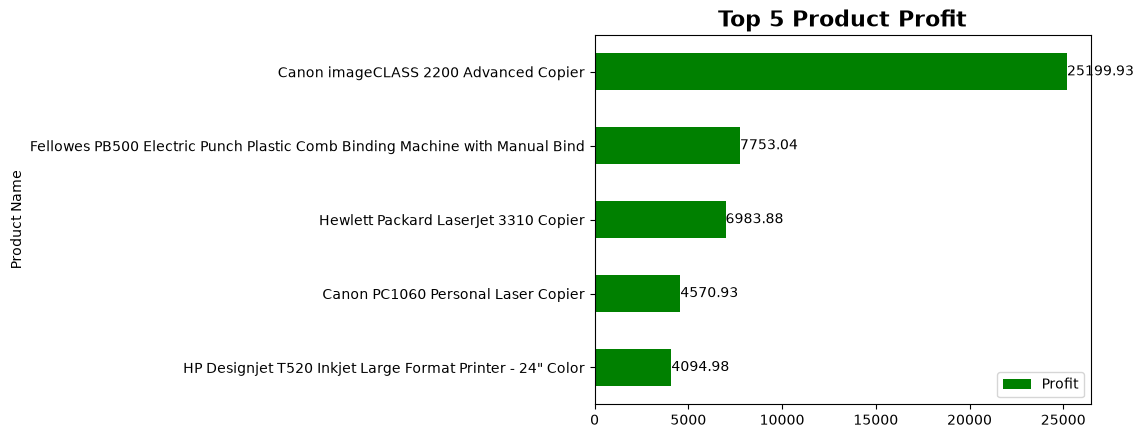

In [102]:
x = Top_5_Product_Sales.sort_values(by='Profit').plot(
    kind='barh',
    x = 'Product Name',
    y = 'Profit',
    color = 'green'
)
plt.title(
    'Top 5 Product Profit',
    fontsize=16, 
    fontweight='bold'
)
x.bar_label(x.containers[0], fmt='%.2f')

##### Canon Image Class 2200 : هو المنتج الاعلي ربحاً علي مدار السنوات 📌

##### 2-Pie chart (الربح لكل فئة)

Text(0.5, 1.0, 'Category Profit')

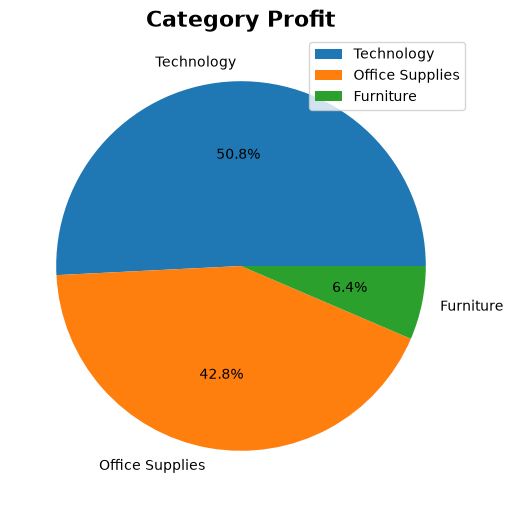

In [103]:
Top_5_Product_Sales = df.groupby('Category').Profit.sum().reset_index(name = 'Profit').sort_values(by='Profit',ascending=False).head(5).set_index('Category')
y = Top_5_Product_Sales.plot(
    figsize=(12,6),
    kind='pie',
    y = 'Profit',
    autopct='%.1f%%'
)
plt.title(
    'Category Profit',
    fontsize=16, 
    fontweight='bold'
 )
# y.legend(
#     loc='lower left',
#     bbox_to_anchor=(-1.2, 0.5)
# )

##### Technology Category حقق اعلي ربح  📌

### تحليل مبيعات المدن

In [104]:
Orders  = df.groupby('Order ID').City.max().reset_index(name='City')
# Number of orders in each city 
Top_5_Cities_Sales = Orders.groupby('City').size().reset_index(name = 'Orders Count').sort_values('Orders Count',ascending=False).head()

<Figure size 1000x600 with 0 Axes>

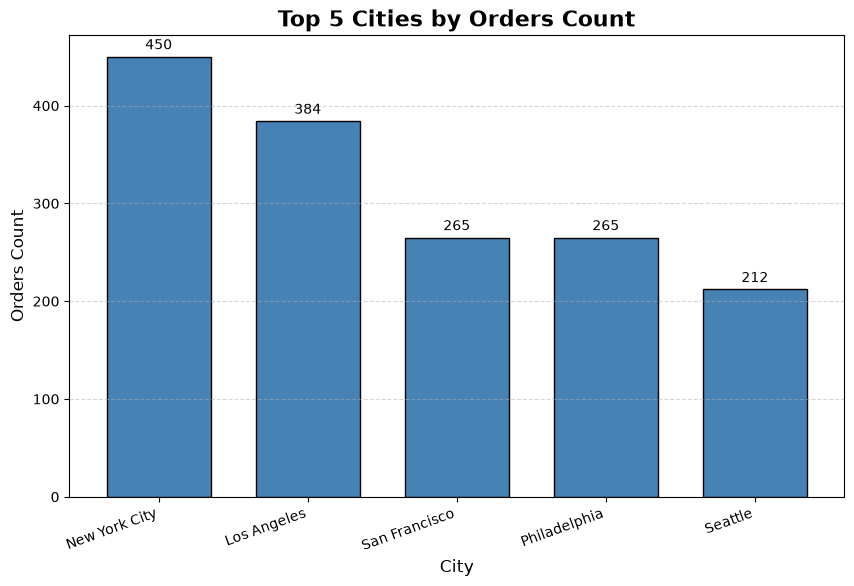

In [105]:
plt.figure(figsize=(10, 6))

ax = Top_5_Cities_Sales.plot(
    kind='bar',
    x='City',
    y='Orders Count',
    color='steelblue',
    edgecolor='black',
    width=0.7,
    figsize=(10,6),
    legend=False
)

plt.title('Top 5 Cities by Orders Count', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Orders Count', fontsize=12)

plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# عرض القيم فوق الأعمدة
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)


plt.show()

#### هنا بنوضح ايه المدن الي حققت أعلي مبيعات 📌

# Q/A

In [132]:
# الربع الاخير من السنة هو اعلي مبيعاتي 
Last_Quarter_df = df[df['Order Date'].dt.quarter == 4 ]
Last_Quarter_df.groupby('Category').Sales.sum()

Category
Furniture          301191.5322
Office Supplies    257886.3490
Technology         318999.6780
Name: Sales, dtype: float64

## Q1 ليه المبيعات بترتفع في الربع الأخير من السنة ؟ 🔑

### 1 - ممكن بسبب الخصومات

In [134]:
Discount = df.groupby(df['Order Date'].dt.quarter).Discount.median()
Discount

Order Date
1    0.00
2    0.20
3    0.15
4    0.20
Name: Discount, dtype: float64

[Text(0, 0, '0.00'),
 Text(0, 0, '0.20'),
 Text(0, 0, '0.15'),
 Text(0, 0, '0.20')]

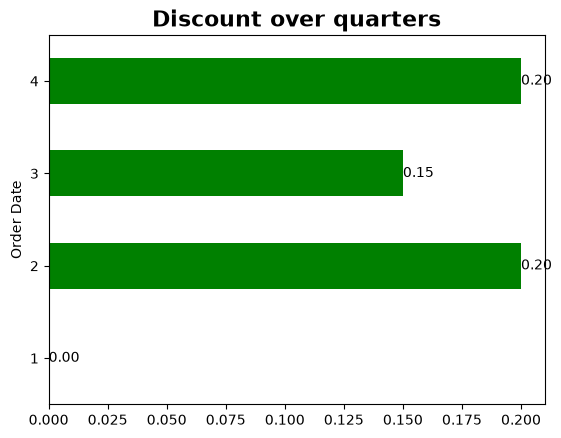

In [135]:
x = Discount.plot(
    kind='barh',
    y='Order Date',
    color = 'green'
)

plt.title(
    'Discount over quarters',
    fontsize=16, 
    fontweight='bold'
)
x.bar_label(x.containers[0], fmt='%.2f')

#### الربع الاول و التاني بيتم فيهم تطبيق خصومات بمتوسط (2%) 📌

### 2- ممكن بسبب ان فيه منتجات كتير بتنزل في الربع الأخير من السنة مثلاً 

In [146]:
# اول مرة المنتج ده اتباع 

First_Time_Buy = df.groupby('Product Name')['Order Date'].min().reset_index(name = 'Initial Date')
First_Time_Buy

,Product Name,Initial Date
0,"""While you Were Out"" Message Book, One Form pe...",2019-09-03
1,"#10 Gummed Flap White Envelopes, 100/Box",2017-11-03
2,#10 Self-Seal White Envelopes,2018-04-08
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",2016-09-21
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",2016-06-06
...,...,...
1845,iKross Bluetooth Portable Keyboard + Cell Phon...,2017-04-30
1846,iOttie HLCRIO102 Car Mount,2016-07-14
1847,iOttie XL Car Mount,2019-09-11
1848,invisibleSHIELD by ZAGG Smudge-Free Screen Pro...,2016-09-07


In [150]:
Product_Release_Vs_Quarters = First_Time_Buy.groupby(First_Time_Buy['Initial Date'].dt.quarter)['Product Name'].count()

Text(0.5, 1.0, 'Number of products released for each quarter')

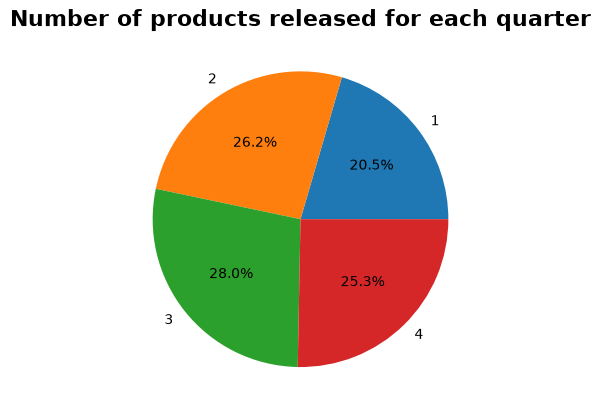

In [160]:
Product_Release_Vs_Quarters.plot(
    kind='pie',
    y = 'Initial Date',
    autopct='%.1f%%'
)
plt.title(
    'Number of products released for each quarter',
    fontsize=16, 
    fontweight='bold'
 )

#### المنتجات الجديدة بتنزل بشكل اكبر في الربع التالت من السنة 📌

# استخراج الملف النهائي 🗃️

In [162]:
df.to_csv('Cleaned_Superstore.csv')